## Textbook code

In [338]:
# coding: utf-8
import sys
import os
sys.path.append('./official_github/')  # 부모 디렉터리의 파일을 가져올 수 있도록 설정
import numpy as np
import matplotlib.pyplot as plt
from dataset.mnist import load_mnist
from common.multi_layer_net import MultiLayerNet
from common.util import shuffle_dataset
from common.trainer import Trainer

In [339]:


# (x_train, t_train), (x_test, t_test) = load_mnist(normalize=True)

# # 결과를 빠르게 얻기 위해 훈련 데이터를 줄임
# x_train = x_train[:500]
# t_train = t_train[:500]

# # 20%를 검증 데이터로 분할
# validation_rate = 0.20
# validation_num = int(x_train.shape[0] * validation_rate)
# x_train, t_train = shuffle_dataset(x_train, t_train)
# x_val = x_train[:validation_num]
# t_val = t_train[:validation_num]
# x_train = x_train[validation_num:]
# t_train = t_train[validation_num:]


# def __train(lr, weight_decay, epocs=50):
#     network = MultiLayerNet(input_size=784,
#                             hidden_size_list=[100, 100, 100, 100, 100, 100],
#                             output_size=10, weight_decay_lambda=weight_decay)
#     trainer = Trainer(network, x_train, t_train, x_val, t_val,
#                       epochs=epocs, mini_batch_size=100,
#                       optimizer='sgd',
#                       optimizer_param={'lr': lr}, verbose=False)
#     trainer.train()

#     return trainer.test_acc_list, trainer.train_acc_list


# # 하이퍼파라미터 무작위 탐색======================================
# optimization_trial = 100
# results_val = {}
# results_train = {}
# for _ in range(optimization_trial):
#     # 탐색한 하이퍼파라미터의 범위 지정===============
#     weight_decay = 10 ** np.random.uniform(-8, -4)
#     lr = 10 ** np.random.uniform(-6, -2)
#     # ================================================

#     val_acc_list, train_acc_list = __train(lr, weight_decay)
#     print("val acc:" + str(val_acc_list[-1]) + " | lr:" + str(lr) + ", weight decay:" + str(weight_decay))
#     key = "lr:" + str(lr) + ", weight decay:" + str(weight_decay)
#     results_val[key] = val_acc_list
#     results_train[key] = train_acc_list


In [340]:
# # 그래프 그리기========================================================
# print("=========== Hyper-Parameter Optimization Result ===========")
# graph_draw_num = 20
# col_num = 5
# row_num = int(np.ceil(graph_draw_num / col_num))
# i = 0

# for key, val_acc_list in sorted(results_val.items(), key=lambda x: x[1][-1], reverse=True):
#     print("Best-" + str(i+1) + "(val acc:" + str(val_acc_list[-1]) + ") | " + key)

#     plt.subplot(row_num, col_num, i+1)
#     plt.title("Best-" + str(i+1))
#     plt.ylim(0.0, 1.0)
#     if i % 5:
#         plt.yticks([])
#     plt.xticks([])
#     x = np.arange(len(val_acc_list))
#     plt.plot(x, val_acc_list)
#     plt.plot(x, results_train[key], "--")
#     i += 1

#     if i >= graph_draw_num:
#         break

# plt.show()



## My code

In [341]:
import sys, os, math, random
sys.path.append('./official_github/')
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt
sys.path.append('./official_github/')

from dataset.mnist import load_mnist
from my_models import MultiLayerNet, SGD

In [342]:
(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True)

# 결과를 빠르게 얻기 위해 훈련 데이터를 줄임
x_train = x_train[:500]
t_train = t_train[:500]

# 20%를 검증 데이터로 분할
validation_rate = 0.20
validation_num = int(x_train.shape[0] * validation_rate)
x_train, t_train = shuffle_dataset(x_train, t_train)
x_val, t_val = x_train[:validation_num], t_train[:validation_num]
x_train, t_train = x_train[validation_num:], t_train[validation_num:]



In [343]:
def get_new_range(valid_acc_dict, top=10):
    sorted_list = sorted(valid_acc_dict.items(), key=lambda x: x[1][-1], reverse=True)
    # sorted_list = sorted(sorted_list, key=lambda x: x[0])
    sorted_list = sorted(sorted_list[:top+1], key=lambda x: x[0])
    min_value, max_value = sorted_list[0][0], sorted_list[-1][0]
    
    return min_value, max_value

===== 1th trial =====
lr: 1.0356231211216342
valid acc: 0.13


c:\Users\dieyo\OneDrive - 고려대학교\2_My-Programming\0_DL_from_scratch\my_functions.py:50: RuntimeWarning: divide by zero encountered in log
  return -np.sum(np.log(y[np.arange(batch_size), t])) / batch_size
c:\Users\dieyo\OneDrive - 고려대학교\2_My-Programming\0_DL_from_scratch\my_layers.py:43: RuntimeWarning: invalid value encountered in matmul
  out = x @ self.W + self.b
c:\Users\dieyo\OneDrive - 고려대학교\2_My-Programming\0_DL_from_scratch\my_layers.py:48: RuntimeWarning: invalid value encountered in matmul
  self.dW = self.x.T @ dout


valid acc: 0.07
valid acc: 0.07
valid acc: 0.07
valid acc: 0.07
valid acc: 0.07
lr: 1.2182830548978647
valid acc: 0.07


c:\Users\dieyo\OneDrive - 고려대학교\2_My-Programming\0_DL_from_scratch\my_layers.py:43: RuntimeWarning: overflow encountered in matmul
  out = x @ self.W + self.b


valid acc: 0.07
valid acc: 0.07
valid acc: 0.07
valid acc: 0.07
valid acc: 0.07
lr: 0.9379116165737071
valid acc: 0.07
valid acc: 0.29
valid acc: 0.18
valid acc: 0.12
valid acc: 0.3
valid acc: 0.26
lr: 1.4010216275918201
valid acc: 0.12
valid acc: 0.07
valid acc: 0.07
valid acc: 0.07
valid acc: 0.07
valid acc: 0.07
lr: 1.2945760339087296
valid acc: 0.07
valid acc: 0.07
valid acc: 0.07
valid acc: 0.07
valid acc: 0.07
valid acc: 0.07
lr: 1.701709324222768
valid acc: 0.18
valid acc: 0.07
valid acc: 0.07
valid acc: 0.07
valid acc: 0.07
valid acc: 0.07
lr: 1.6116140296476253
valid acc: 0.11


c:\Users\dieyo\OneDrive - 고려대학교\2_My-Programming\0_DL_from_scratch\my_functions.py:27: RuntimeWarning: invalid value encountered in subtract
  x = x - np.max(x, axis=0)


valid acc: 0.07
valid acc: 0.07
valid acc: 0.07
valid acc: 0.07
valid acc: 0.07
lr: 1.3643812314230501
valid acc: 0.19
valid acc: 0.07
valid acc: 0.07
valid acc: 0.07
valid acc: 0.07
valid acc: 0.07
lr: 1.9214169767001648
valid acc: 0.09
valid acc: 0.07
valid acc: 0.07
valid acc: 0.07
valid acc: 0.07
valid acc: 0.07
lr: 1.6015232520712357
valid acc: 0.12
valid acc: 0.07
valid acc: 0.07
valid acc: 0.07
valid acc: 0.07
valid acc: 0.07
lr: 0.6795416107434393
valid acc: 0.1
valid acc: 0.27
valid acc: 0.2
valid acc: 0.18
valid acc: 0.18
valid acc: 0.18
lr: 0.4520242144657014
valid acc: 0.14
valid acc: 0.26
valid acc: 0.59
valid acc: 0.07
valid acc: 0.07
valid acc: 0.07
lr: 0.7274103383462254
valid acc: 0.21
valid acc: 0.32
valid acc: 0.19
valid acc: 0.33
valid acc: 0.21
valid acc: 0.25
lr: 1.7543263691183
valid acc: 0.07
valid acc: 0.07
valid acc: 0.07
valid acc: 0.07
valid acc: 0.07
valid acc: 0.07
lr: 1.4583922022223175
valid acc: 0.06
valid acc: 0.07
valid acc: 0.07
valid acc: 0.07
valid

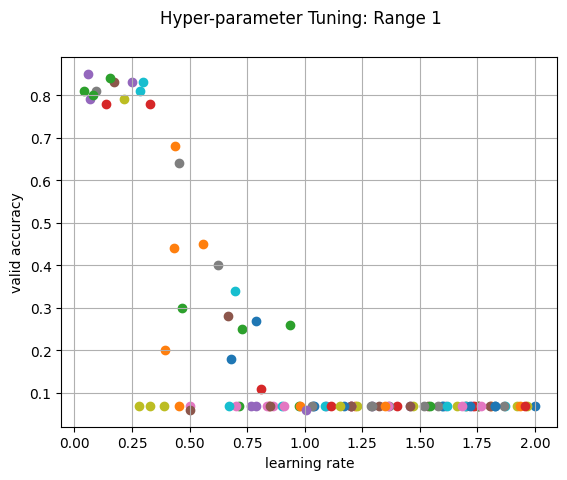

KeyError: 299

In [344]:
total_trial = 4
outputs_dict = {}
min_value, max_value = 0, 2

for trial_idx in range(1, total_trial+1):
    print(f'===== {trial_idx}th trial =====')
    outputs_dict[trial_idx] = defaultdict(list)
    
    trial = 100
    for _ in range(trial):
        lr = random.uniform(min_value, max_value)
        print(f'lr: {lr}')
        network = MultiLayerNet(784, [100, 100, 100, 100, 100, 100], 10,)
        optimizer = SGD(lr=lr)
        for i in range(300):
            batch_mask = np.random.choice(x_train.shape[0], 100)
            x_batch = x_train[batch_mask]
            t_batch = t_train[batch_mask]

            grads = network.gradient(x_batch, t_batch)
            optimizer.update(network.params, grads)

            if i % 50 == 0:
                acc = network.accuracy(x_val, t_val)
                print(f'valid acc: {acc}')
                outputs_dict[trial_idx][lr].append(acc)
    
    trial //= 2
    for key, value in outputs_dict[trial_idx].items():
        # print(key, value[-1])
        plt.scatter(key, value[-1], label=key)

    # plt.legend()
    plt.grid()
    # plt.ylim(0.6, 1.01)
    # plt.xlim(-1, 1)
    plt.xlabel('learning rate')
    plt.ylabel('valid accuracy')
    plt.suptitle(f'Hyper-parameter Tuning: Range {trial_idx}')
    plt.show()

    min_value, max_value = get_new_range(outputs_dict[trial_idx], top=2)
    print(f'{trial_idx} trial with {trial}:  {min_value}, {max_value}')

    